In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
import warnings
warnings.filterwarnings('ignore')

cc_df = pd.read_csv('../data/raw/creditcard.csv')
print("Shape:", cc_df.shape)
print(cc_df.info())
cc_df.head()

Shape: (284807, 31)
<class 'pandas.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [2]:
print("Missing values:\n", cc_df.isnull().sum().sum())
print(f"\nDuplicates: {cc_df.duplicated().sum()}")
cc_df.drop_duplicates(inplace=True)
print(f"Shape after dedup: {cc_df.shape}")

Missing values:
 0

Duplicates: 1081
Shape after dedup: (283726, 31)


        Count  Percentage
Class                    
0      283253     99.8333
1         473      0.1667


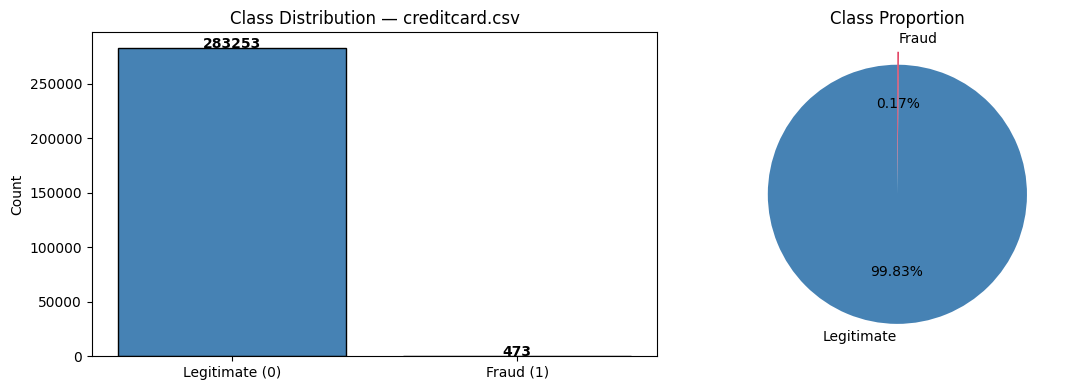

In [3]:
class_counts = cc_df['Class'].value_counts()
class_pct    = cc_df['Class'].value_counts(normalize=True) * 100

print(pd.DataFrame({'Count': class_counts, 'Percentage': class_pct.round(4)}))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(['Legitimate (0)', 'Fraud (1)'], class_counts.values,
            color=['steelblue', 'crimson'], edgecolor='black')
axes[0].set_title('Class Distribution — creditcard.csv')
axes[0].set_ylabel('Count')
for i, v in enumerate(class_counts.values):
    axes[0].text(i, v + 100, str(v), ha='center', fontweight='bold')

axes[1].pie(class_counts.values, labels=['Legitimate', 'Fraud'],
            autopct='%1.2f%%', colors=['steelblue', 'crimson'],
            startangle=90, explode=(0, 0.1))
axes[1].set_title('Class Proportion')

plt.tight_layout()
plt.savefig('../data/processed/class_distribution_cc.png', dpi=150)
plt.show()

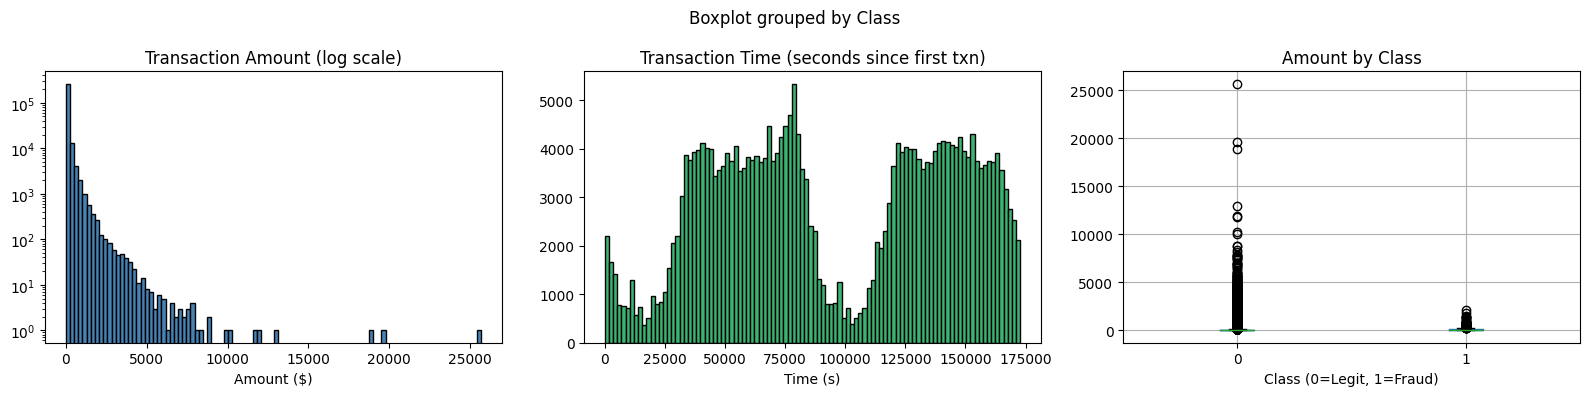

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].hist(cc_df['Amount'], bins=100, color='steelblue', edgecolor='black', log=True)
axes[0].set_title('Transaction Amount (log scale)')
axes[0].set_xlabel('Amount ($)')

axes[1].hist(cc_df['Time'], bins=100, color='mediumseagreen', edgecolor='black')
axes[1].set_title('Transaction Time (seconds since first txn)')
axes[1].set_xlabel('Time (s)')

# Amount by class
cc_df.boxplot(column='Amount', by='Class', ax=axes[2])
axes[2].set_title('Amount by Class')
axes[2].set_xlabel('Class (0=Legit, 1=Fraud)')

plt.tight_layout()
plt.savefig('../data/processed/cc_amount_time_dist.png', dpi=150)
plt.show()

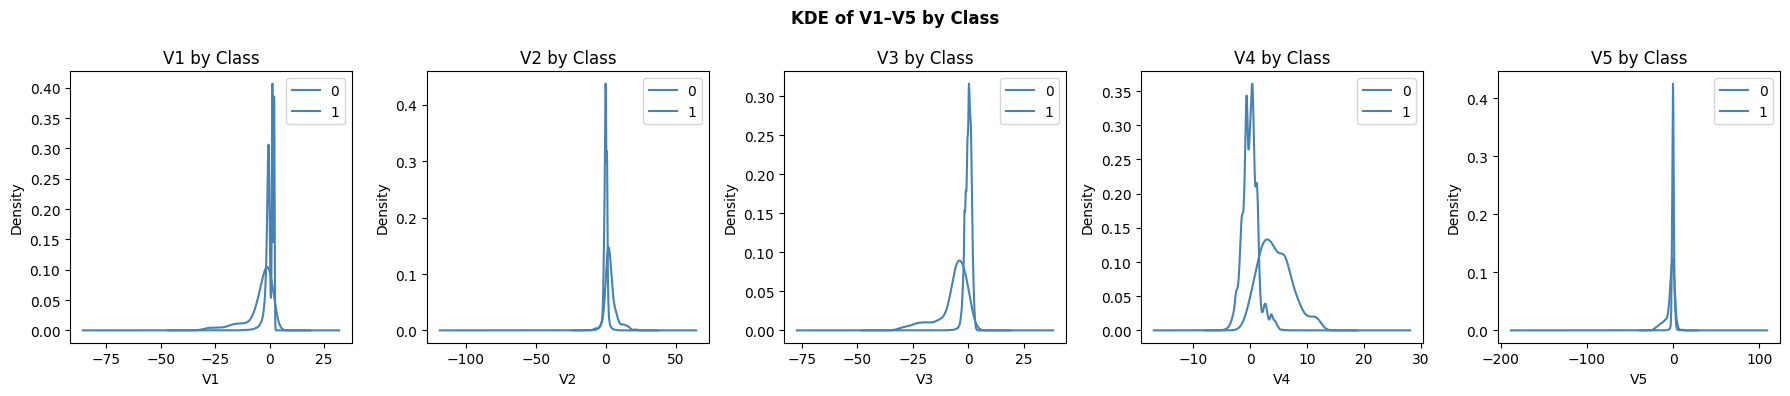

In [5]:
v_cols = [f'V{i}' for i in range(1, 6)]
fig, axes = plt.subplots(1, 5, figsize=(18, 4))

for ax, col in zip(axes, v_cols):
    cc_df.groupby('Class')[col].plot(kind='kde', ax=ax, legend=True,
                                     color=['steelblue', 'crimson'])
    ax.set_title(f'{col} by Class')
    ax.set_xlabel(col)

plt.suptitle('KDE of V1–V5 by Class', fontweight='bold')
plt.tight_layout()
plt.savefig('../data/processed/cc_pca_kde.png', dpi=150)
plt.show()

Top 10 features correlated with Class:
 V17    0.313498
V14    0.293375
V12    0.250711
V10    0.206971
V16    0.187186
V3     0.182322
V7     0.172347
V11    0.149067
V4     0.129326
V18    0.105340
Name: Class, dtype: float64


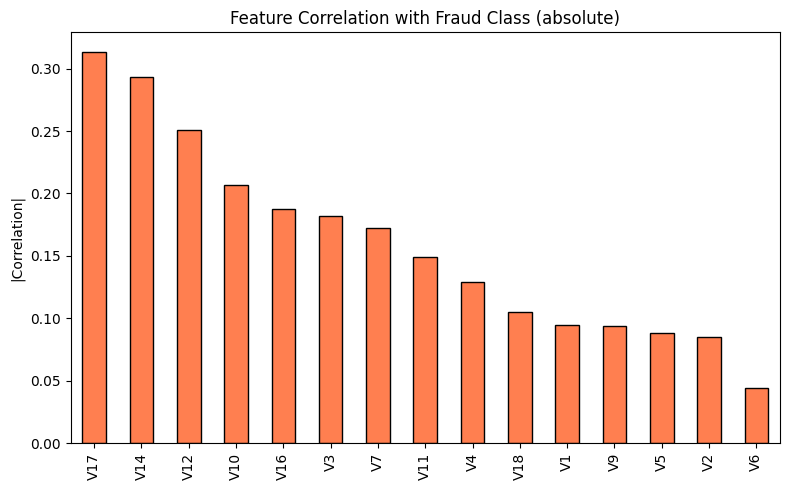

In [6]:
corr = cc_df.corr()['Class'].drop('Class').abs().sort_values(ascending=False)
print("Top 10 features correlated with Class:\n", corr.head(10))

plt.figure(figsize=(8, 5))
corr.head(15).plot(kind='bar', color='coral', edgecolor='black')
plt.title('Feature Correlation with Fraud Class (absolute)')
plt.ylabel('|Correlation|')
plt.tight_layout()
plt.savefig('../data/processed/cc_correlation.png', dpi=150)
plt.show()

In [7]:
scaler = StandardScaler()
cc_df['Amount_scaled'] = scaler.fit_transform(cc_df[['Amount']])
cc_df['Time_scaled']   = scaler.fit_transform(cc_df[['Time']])

feature_cols = [f'V{i}' for i in range(1, 29)] + ['Amount_scaled', 'Time_scaled']

X = cc_df[feature_cols]
y = cc_df['Class']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print("Train class dist:\n", y_train.value_counts())

Train: (226980, 30), Test: (56746, 30)
Train class dist:
 Class
0    226602
1       378
Name: count, dtype: int64


Before SMOTE:
 Class
0    226602
1       378
Name: count, dtype: int64

After SMOTE:
 Class
0    226602
1    226602
Name: count, dtype: int64


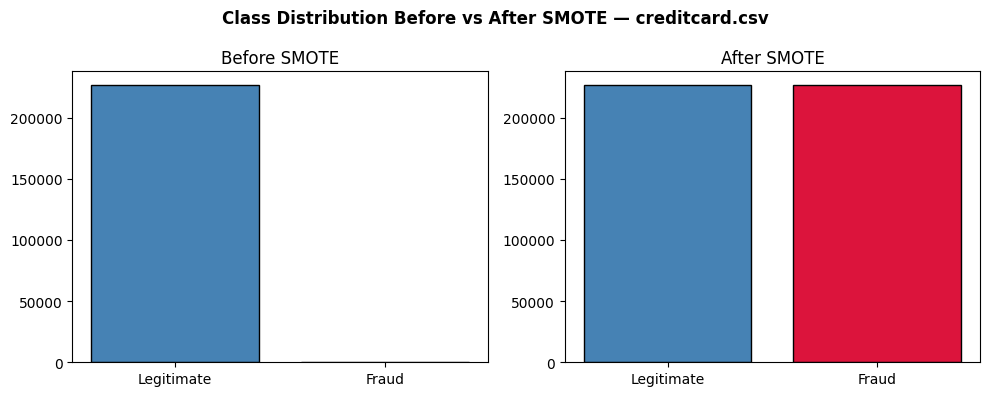

In [8]:
print("Before SMOTE:\n", y_train.value_counts())

smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print("\nAfter SMOTE:\n", pd.Series(y_train_sm).value_counts())

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].bar(['Legitimate', 'Fraud'], y_train.value_counts().values,
            color=['steelblue', 'crimson'], edgecolor='black')
axes[0].set_title('Before SMOTE')

axes[1].bar(['Legitimate', 'Fraud'],
            pd.Series(y_train_sm).value_counts().sort_index().values,
            color=['steelblue', 'crimson'], edgecolor='black')
axes[1].set_title('After SMOTE')

plt.suptitle('Class Distribution Before vs After SMOTE — creditcard.csv', fontweight='bold')
plt.tight_layout()
plt.savefig('../data/processed/smote_comparison_cc.png', dpi=150)
plt.show()

In [9]:
import joblib

cc_processed = cc_df.copy()
cc_processed.to_csv('../data/processed/creditcard_processed.csv', index=False)

joblib.dump((X_train_sm, X_test, y_train_sm, y_test),
            '../data/processed/cc_train_test_splits.pkl')
print("Saved creditcard processed data and splits.")

Saved creditcard processed data and splits.
